In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import csv
import os
import random

# Filter out non-complete and faulty records

In [2]:
data = pd.read_csv('all_poems.csv', engine='python')

### Drop records with empty cells

In [3]:
filled_data = data.dropna()

### Drop poems where the text is too short (poem is possibly faultily extracted)

In [4]:
few_char_poems = filled_data[
    filled_data["Poem"].str.strip().str.len() <= 20
]
few_char_poems

,Title,Poet,Poem,Tags,Emotion,PoetBirth,Period,Format
3080,Amidwives: Two Portraits,Todd Boss,i. a wife will wean,"Living,Marriage & Companionship,Relationships,...",Anger,1968.0,1971-Present,sl-sp
3445,And the Ghosts,Graham Foust,they own everything,"Mythology & Folklore,Ghosts & the Supernatural",Anger,1970.0,1971-Present,sl-sp
3750,The Fourth Hour of the Night,Frank Bidart,"I Out of scarcity,—","Love,Heartache & Loss,Activities,Travels & Jou...",Anger,1939.0,1941-1970,sl-sp
6496,A Poem for Children with Thoughts on Death,Jupiter Hammon,I,"Death,Religion,Christianity,God & the Divine,P...",Anger,1711.0,1550-1780,sl-sp
7573,Call as You Will,Todd Boss,—retracing,"Relationships,Pets,Nature,Animals",Anger,1968.0,1971-Present,sl-sp


In [5]:
filled_data = filled_data[
    filled_data["Poem"].str.strip().str.len() > 20
]

In [6]:
filled_data.shape

(6137, 8)

# Filter for poems that have recurring poets
Poets with more than 7 appearances in the filtered dataset.

In [7]:
x = 7

stats_poet = (
    filled_data
    .groupby(["Poet"])
    .size()
    .reset_index(name="Count")
)

stats_poet = stats_poet[stats_poet["Count"] > x] \
    .sort_values(by="Count", ascending=False)
stats_poet

,Poet,Count
37,"Alfred, Lord Tennyson",51
1404,William Wordsworth,42
1401,William Shakespeare,42
402,Emily Dickinson,33
1390,William Blake,27
...,...,...
1299,Ted Kooser,8
97,Anne Waldman,8
31,Alberto Ríos,8
1384,Wendy Xu,8


In [8]:
filtered_data = filled_data[
    filled_data["Poet"].isin(stats_poet["Poet"])
]

filtered_data

,Title,Poet,Poem,Tags,Emotion,PoetBirth,Period,Format
5,Invisible Fish,Joy Harjo,Invisible fish swim this ghost ocean now descr...,"Living,Time & Brevity,Relationships,Family & A...",Fear,1951.0,1941-1970,ll-sp
6,Don’t Bother the Earth Spirit,Joy Harjo,Don’t bother the earth spirit who lives here. ...,"Religion,The Spiritual,Mythology & Folklore,Fa...",Joy,1951.0,1941-1970,ll-sp
77,Elephant Armageddon,Gerard Malanga,NYTimes headline for September 4th 2012:\r\r\r...,"Living,Death,Sorrow & Grieving,Activities,Trav...",Fear,1943.0,1941-1970,sl-sp
151,One Bite,Aimee Nezhukumatathil,"Miracle fruit changes the tongue. One bite, \r...","Activities,Eating & Drinking",Anger,1974.0,1971-Present,sl-sp
152,Hell Pig,Aimee Nezhukumatathil,"To keep me from staying out late at night, \r\...","Living,Coming of Age,Love,Desire,Nature,Animal...",Joy,1974.0,1971-Present,ll-sp
...,...,...,...,...,...,...,...,...
8769,The Love Song of J. Alfred Prufrock,T. S. Eliot,S’io credesse che mia risposta fosse\r\r\r\nA ...,"Living,Disappointment & Failure,Growing Old,Ti...",Fear,1888.0,1901-1940,sl-lp
8773,Salvation,Stephen Dunn,"Finally, I gave up on obeisance,\r\r\nand refu...","Living,Religion,Faith & Doubt",Joy,1939.0,1941-1970,sl-sp
8776,The Guru,A. F. Moritz,Here comes the wise man in the story of sick t...,"Religion,Arts & Sciences,Humor & Satire,Social...",Fear,1947.0,1941-1970,ll-sp
8778,Stomackes,Albert Goldbarth,We know far more about the philosophical under...,"Activities,Eating & Drinking,Religion,Christia...",Fear,1948.0,1941-1970,ll-sp


# Stats of narrowed dataset

In [9]:
# By emotion
stats_emotion = (
    filtered_data
    .groupby(["Emotion"])
    .size()
    .reset_index(name="Count")
)
stats_emotion

,Emotion,Count
0,Anger,355
1,Fear,820
2,Joy,744
3,Love,241
4,Sadness,483
5,Surprise,210


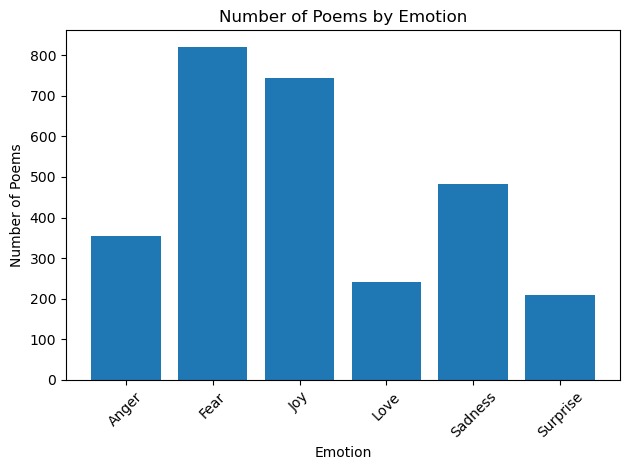

In [10]:
plt.figure()
plt.bar(stats_emotion["Emotion"], stats_emotion["Count"])

plt.xlabel("Emotion")
plt.ylabel("Number of Poems")
plt.title("Number of Poems by Emotion")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("figures/fig_filtered_emotion_stats.png", dpi=300)
plt.show()

In [11]:
# By period
stats_period = (
    filtered_data
    .groupby(["Period"], observed=False)
    .size()
    .reset_index(name="Count")
)
stats_period

,Period,Count
0,1550-1780,313
1,1781-1900,724
2,1901-1940,346
3,1941-1970,894
4,1971-Present,557
5,Pre-1550,19


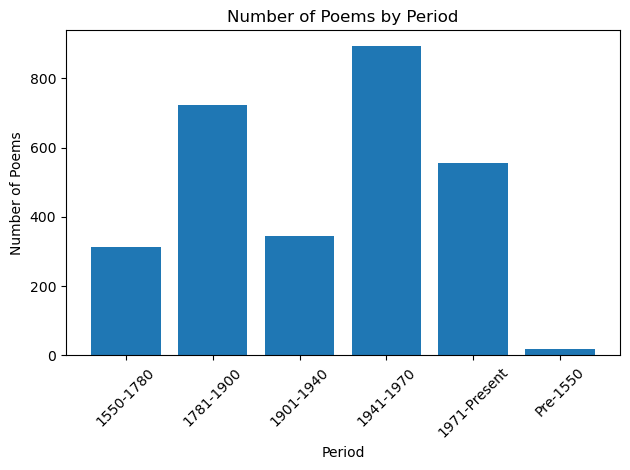

In [12]:
plt.figure()
plt.bar(stats_period["Period"], stats_period["Count"])

plt.xlabel("Period")
plt.ylabel("Number of Poems")
plt.title("Number of Poems by Period")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("figures/fig_filtered_period_stats.png", dpi=300)
plt.show()

In [13]:
stats_format = (
    filtered_data
    .groupby(["Format"])
    .size()
    .reset_index(name="Count")
)
stats_format

,Format,Count
0,ll-lp,68
1,ll-sp,1428
2,sl-lp,610
3,sl-sp,747


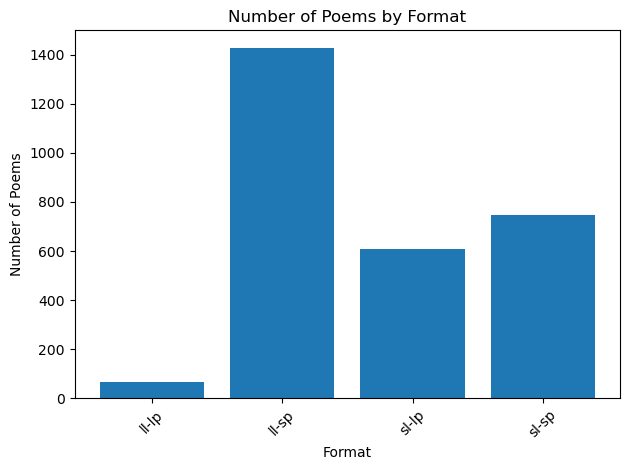

In [25]:
plt.figure()
plt.bar(stats_format["Format"], stats_format["Count"])

plt.xlabel("Format")
plt.ylabel("Number of Poems")
plt.title("Number of Poems by Format")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("figures/fig_filtered_format_stats.png", dpi=300)
plt.show()

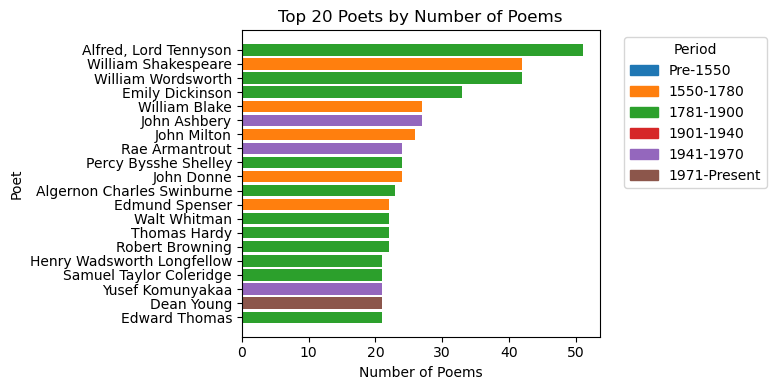

In [15]:
stats_poet_plus_period = stats_poet.merge(
    filled_data[["Poet", "Period"]].drop_duplicates(),
    on="Poet",
    how="left"
)
top20_poets = (
    stats_poet_plus_period 
    .sort_values(by="Count", ascending=False)
    .head(20)
)

period_colors = {
    'Pre-1550': 'tab:blue',
    '1550-1780': 'tab:orange',
    '1781-1900': 'tab:green',
    '1901-1940': 'tab:red',
    '1941-1970': 'tab:purple',
    '1971-Present': 'tab:brown'
}

colors = top20_poets["Period"].map(period_colors)

plt.figure(figsize=(8,4))
plt.barh(top20_poets["Poet"], top20_poets["Count"], color=colors)

plt.xlabel("Number of Poems")
plt.ylabel("Poet")
plt.title("Top 20 Poets by Number of Poems")
plt.gca().invert_yaxis()
handles = [
    mpatches.Patch(color=color, label=period)
    for period, color in period_colors.items()
]

plt.legend(handles=handles, title="Period", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("figures/fig_filtered_poet_stats.png", dpi=300)
plt.show()

# Write narrowed down dataset into metadata .csv

In [16]:
filtered_data.shape

(2853, 8)

In [17]:
filtered_data.to_csv(
    'filtered_poems.csv',
    index=False,
    quoting=csv.QUOTE_ALL
)

# Filter out embedding vectors in embedding .npy files

In [18]:
# order of csv matches order in npy
indices = filtered_data.index.to_numpy()

In [19]:
indices

array([   5,    6,   77, ..., 8776, 8778, 8779])

In [20]:
input_folder = "poem_embeddings"
output_folder = "filtered_embeddings"

os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.endswith(".npy"):
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        # Load array
        arr = np.load(input_path)
        # Select rows
        filtered_arr = arr[indices].astype(np.float64)
        print(filename, arr.shape, filtered_arr.shape)
        # Save new array
        np.save(output_path, filtered_arr)

w2v_d100_w5_cbow_avg.npy (13745, 100) (2853, 100)
w2v_d100_w5_cbow_idf.npy (13745, 100) (2853, 100)
w2v_d100_w5_cbow_sif.npy (13745, 100) (2853, 100)
d2v_line_d100_w5_dm.npy (13745, 100) (2853, 100)
d2v_line_d100_w5_dbow.npy (13745, 100) (2853, 100)
w2v_d100_w5_sg_avg.npy (13745, 100) (2853, 100)
w2v_d100_w5_sg_idf.npy (13745, 100) (2853, 100)
w2v_d100_w5_sg_sif.npy (13745, 100) (2853, 100)
d2v_poem_d100_w5_dbow.npy (13745, 100) (2853, 100)
d2v_poem_d100_w5_dm.npy (13745, 100) (2853, 100)
baseline.npy (13745, 100) (2853, 100)


### Sanity check

In [21]:
# Pick an index from filtered_data
rand_idx = 8776

# Load original and filtered arrays
orig = np.load(os.path.join(input_folder, "baseline.npy"))
filtered = np.load(os.path.join(output_folder, "baseline.npy"))

# Find where this index ended up in the filtered array
filtered_position = np.where(indices == rand_idx)[0][0]
original_vector = orig[rand_idx]
filtered_vector = filtered[filtered_position]

# Compare the vectors
print("Index chosen:", rand_idx)
print("Position in filtered:", filtered_position)
print("Match:", np.allclose(original_vector, filtered_vector))

Index chosen: 8776
Position in filtered: 2850
Match: True


In [22]:
reread_data = pd.read_csv('filtered_poems.csv', engine='python')

In [23]:
reread_data[filtered_position:filtered_position+1]

,Title,Poet,Poem,Tags,Emotion,PoetBirth,Period,Format
2850,The Guru,A. F. Moritz,Here comes the wise man in the story of sick t...,"Religion,Arts & Sciences,Humor & Satire,Social...",Fear,1947.0,1941-1970,ll-sp


In [24]:
data[rand_idx:rand_idx+1]

,Title,Poet,Poem,Tags,Emotion,PoetBirth,Period,Format
8776,The Guru,A. F. Moritz,Here comes the wise man in the story of sick t...,"Religion,Arts & Sciences,Humor & Satire,Social...",Fear,1947.0,1941-1970,ll-sp
